![Logo 1](https://git.wmi.amu.edu.pl/AITech/Szablon/raw/branch/master/Logotyp_AITech1.jpg)
<div class="alert alert-block alert-info">
<h1> Komputerowe wspomaganie tłumaczenia </h1>
<h2> 4,5. <i>Klasyfikacja tematyczna (terminologii ciąg dalszy)</i> [laboratoria]</h2> 
<h3>Rafał Jaworski (2021)</h3>
</div>

![Logo 2](https://git.wmi.amu.edu.pl/AITech/Szablon/raw/branch/master/Logotyp_AITech2.jpg)

# Komputerowe wspomaganie tłumaczenia

# Zajęcia 4 i 5 - klasyfikacja tematyczna (terminologii ciąg dalszy)

Na poprzednich zajęciach opracowaliśmy nasz własny ekstraktor terminologii. Mówiliśmy również, jak ważna jest ekstrakcja terminów specjalistycznych. Dziś zajmiemy się zagadnieniem, w jaki sposób wyciągnąć z tekstu terminy, które naprawdę są specjalistyczne.

Dlaczego nasze dotychczasowe rozwiązanie mogło nie spełniać tego warunku? Wykonajmy następujące ćwiczenie:

### Ćwiczenie 1: Zgromadź korpus w języku angielskim składający się z co najmniej 100 dokumentów, z których każdy zawiera co najmniej 100 zdań. Wykorzystaj stronę https://opus.nlpl.eu/. Dobrze, aby dokumenty pochodziły z różnych dziedzin (np. prawo Unii Europejskiej, manuale programistyczne, medycyna). Ściągnięty korpus zapisz na swoim dysku lokalnym, nie załączaj go do niniejszego notatnika.

Taki korpus pozwoli nam zaobserwować, co się stanie, jeśli do ekstrakcji terminologii będziemy stosowali wyłącznie kryterium częstościowe. Aby wykonać odpowiedni eksperyment musimy uruchomić ekstraktor z poprzednich zajęć.

In [ ]:
import os
import random

input_dir = "./tmp"

output_dir = "./korpus"
os.makedirs(output_dir, exist_ok=True)

lines = []

for filename in os.listdir(input_dir):
    filepath = os.path.join(input_dir, filename)

    if os.path.isfile(filepath):
        with open(filepath, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    lines.append(line)

random.shuffle(lines)
documents = []

for i in range(0, len(lines), 100):
    chunk = lines[i:i+100]
    if len(chunk) == 100:
        documents.append(chunk)

for i, doc in enumerate(documents[:100]):
    filepath = os.path.join(output_dir, f"doc_{i}.txt")

    with open(filepath, "w", encoding="utf-8") as f:
        f.write(" ".join(doc))


### Ćwiczenie 2: Uruchom ekstraktor terminologii (wykrywacz rzeczowników) z poprzednich zajęć na każdym dokumencie z osobna. Jako wynik ekstraktora w każdym przypadku wypisz 5 najczęściej występujących rzeczowników. Wyniki działania komendy umieść w notatniku.

In [4]:
doc_dir="./korpus"

In [6]:
from collections import Counter
import spacy
import os

nlp = spacy.load("en_core_web_sm")

def extract_terms(text):
    doc = nlp(text)
    allowed_pos = ["NOUN", "PROPN", "VERB", "ADJ"]

    lemmas = [
        token.lemma_.lower()
        for token in doc
        if token.pos_ in allowed_pos
    ]

    return dict(Counter(lemmas))

files = sorted([f for f in os.listdir(doc_dir) if f.endswith('.txt')])


In [7]:
for filename in files:
    file_path = os.path.join(doc_dir, filename)

    with open(file_path, 'r', encoding='utf-8') as f:
        text = f.read()

    tally = extract_terms(text)

    top_5 = sorted(tally.items(), key=lambda x: x[1], reverse=True)[:5]

    terms_output = ", ".join([f"{word} ({count})" for word, count in top_5])
    print(f"{filename}: {terms_output}")

doc_0.txt: article (26), union (23), european (18), member (17), states (15)
doc_1.txt: article (18), european (16), member (15), union (12), constitution (8)
doc_10.txt: member (22), european (18), article (17), council (16), union (16)
doc_11.txt: article (23), european (20), republic (19), president (18), member (14)
doc_12.txt: article (19), european (16), member (13), republic (12), measure (9)
doc_13.txt: member (18), union (15), european (14), article (12), court (10)
doc_14.txt: member (26), european (21), article (21), states (18), council (13)
doc_15.txt: member (21), union (20), article (19), european (19), constitution (12)
doc_16.txt: article (24), european (20), law (14), union (13), member (12)
doc_17.txt: article (26), european (22), member (20), union (18), states (12)
doc_18.txt: member (18), european (16), union (13), law (13), article (13)
doc_19.txt: european (21), member (17), article (16), union (11), bank (10)
doc_2.txt: european (21), article (14), union (12), 

Czy wyniki uzyskane w ten sposób to zawsze terminy specjalistyczne? Niestety może zdarzyć się, że w wynikach pojawią się rzeczowniki, które są po prostu częste w języku, a niekoniecznie charakterystyczne dla przetwarzanych przez nas tekstów. Aby wyniki ekstrakcji były lepsze, konieczne jest zastosowanie bardziej wyrafinowanych metod.

Jedną z tych metod jest znana z dyscypliny Information Retrieval technika zwana TF-IDF. Jej nazwa wywodzi się od **T**erm **F**requency **I**nverted **D**ocument **F**requency. Według tej metody, dla każdego odnalezionego przez nas termu powinniśmy obliczyć czynnik TF-IDF, a następnie wyniki posortować malejąco po wartości tego czynnika.

Jak obliczyć czynnik TF-IDF? Czym jest TF, a czym jest IDF?

Zacznijmy od TF, bo ten czynnik już znamy. Jest to nic innego jak częstość wystąpienia terminu w tekście, który przetwarzamy. Idea TF-IDF skupia się na drugim czynniku - IDF. Słowo *inverted* oznacza, że czynnik ten będzie odwrócony, czyli trafi do mianownika. W związku z tym TF-IDF to w istocie:
$\frac{TF}{DF}$

Czym zatem jest document frequency? Jest to liczba dokumentów, w których wystąpił dany termin. Dokumenty w tym przypadku są rozumiane jako jednostki, na które podzielony jest korpus, nad którym pracujemy (dokładnie taki, jak korpus z ćwiczenia pierwszego).

Zastanówmy się nad sensem tego czynnika. Pamiętajmy, że naszym zadaniem jest ekstracja terminów z tylko jednego dokumentu na raz. Mamy jednak do dyspozycji wiele innych dokumentów, zawierających wiele innych słów i termów. Wartość TF-IDF jest tym większa, im częściej termin występuje w dokumencie, na którym dokonujemy ekstrakcji. Czynnik ten jednak zmniejsza się, jeśli słowo występuje w wielu różnych dokumentach. Zatem, popularne słowa będą miały wysoki czynnik DF i niski TF-IDF. Natomiast najwyższą wartość TF-IDF będą miały terminy, które są częste w przetwarzanym przez nas dokumencie, ale nie występują nigdzie indziej.

### Ćwiczenie 3: Zaimplementuj czynnik TF-IDF i dokonaj ekstrakcji terminologii za jego pomocą, używając korpusu z ćwiczenia nr 1. Czy wyniki różnią się od tych uzyskanych tylko za pomocą TF?

TF-IDF daje inne wyniki, bo usuwa bardzo popularne słowa i skupia się na tych rzadszych, bardziej charakterystycznych. Dzięki temu na górze listy pojawiają się bardziej konkretne i specjalistyczne terminy, zamiast ogólnych słów.

In [9]:
global_df = {}
for filename in files:
    with open(os.path.join(doc_dir, filename), 'r', encoding='utf-8') as f:
        doc = nlp(f.read())
        unique_nouns = {token.lemma_.lower() for token in doc if token.pos_ in ["NOUN", "PROPN"]}
        for noun in unique_nouns:
            global_df[noun] = global_df.get(noun, 0) + 1


def tfidf_extract(text, global_df):
    doc = nlp(text)
    
    tf_tally = {}
    for token in doc:
        if token.pos_ in ["NOUN", "PROPN"]:
            lemma = token.lemma_.lower()
            tf_tally[lemma] = tf_tally.get(lemma, 0) + 1
            
    tfidf_scores = {}
    for lemma, tf in tf_tally.items():
        df = global_df.get(lemma, 1)
        tfidf_scores[lemma] = tf / df
        
    sorted_terms = sorted(tfidf_scores.items(), key=lambda x: x[1], reverse=True)
    
    return sorted_terms

for filename in files:
    file_path = os.path.join(doc_dir, filename)
    with open(file_path, 'r', encoding='utf-8') as f:
        text = f.read()

    tfdif_terms = tfidf_extract(text, global_df)

    top_5 = tfdif_terms[:5]
    terms_output = ", ".join([f"{word} ({score})" for word, score in top_5])
    print(f"{filename}: {terms_output}")

doc_0.txt: lard (3.0), stearin (2.0), sections (1.5), measures.7 (1.0), statutes (1.0)
doc_1.txt: i-10(2)(a (1.0), purpose.2 (1.0), labour.3 (1.0), iii-198(1)(d (1.0), iii-198(1)(b (1.0)
doc_10.txt: algirdas (1.0), mykolas (1.0), brazauskas (1.0), sign (1.0), hit (1.0)
doc_11.txt: tyre (1.0), parameter (1.0), specialisation (1.0), action.3 (1.0), e. (1.0)
doc_12.txt: kot (2.0), mollusc (1.0), i-59 (1.0), iv-441 (1.0), iii-430 (1.0)
doc_13.txt: saturday (1.0), anniversary (1.0), journalism (1.0), verhofstadt (1.0), iii-358(2 (1.0)
doc_14.txt: dôkaz (1.0), toho (1.0), dolupodpísaní (1.0), splnomocnení (1.0), zástupcovia (1.0)
doc_15.txt: functions (1.0), delimitation (1.0), i-28(1).5 (1.0), audits (1.0), regards (1.0)
doc_16.txt: attached.5 (1.0), iii-266 (1.0), practices.2 (1.0), i-30(1 (1.0), crossborder (1.0)
doc_17.txt: procedure.4 (1.0), iv-440(2 (1.0), evolution (1.0), 33(1 (1.0), euro.6 (1.0)
doc_18.txt: islander (2.0), manxman (2.0), grandparent (2.0), procedures.5 (1.0), indulis

Teraz potrafimy już w lepszy sposób wyciągać terminy z dokumentów. Spróbujmy jeszcze czegoś widowiskowego - wygenerujmy tzw. chmurę słów z tekstu przy użyciu biblioteki WordCloud dla artykułu z BBC News (https://www.bbc.com/news/world-europe-56530714):

`sudo pip install wordcloud`

In [10]:
!pip install wordcloud


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


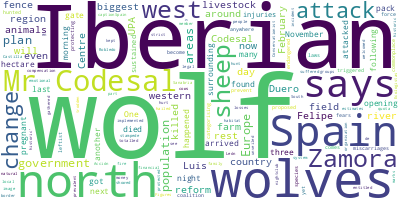

In [14]:
from wordcloud import WordCloud
text = """"This is where it happened," says Felipe Luis Codesal, opening the gate to a three-hectare field on his farm in Zamora, north-west Spain.

One night last November, a pack of wolves got through the fence surrounding the field and attacked Mr Codesal's sheep, many of which were pregnant. When he arrived the next morning, he found 11 animals had been killed. Over the following days, he says, another 36 sheep died from injuries sustained in that attack and miscarriages it triggered.

Mr Codesal fears that such attacks will become even more commonplace if a proposed change to laws protecting the Iberian wolf comes into force.

The leftist coalition government plans to prevent the Iberian wolf from being hunted anywhere by categorising it as an endangered species. The reform is yet to be implemented and could see changes.

Iberian wolves from the Iberian Wolf Centre in Robledo de Sanabria on February 21, 2020 in Zamora, Spain
image captionSpain has Europe's biggest wolf population: These Iberian wolves are kept at Zamora's Iberian wolf centre
"It's like in a nightclub when there's a fire," says Mr Codesal of the wolf attack. "There's a stampede and people get trodden on and hurt. This is the same."

He was not entitled to any compensation and estimates that the financial losses he suffered from this incident totalled around €12-14,000

"It's not even about the money," he says. "It's emotional, because the animals are part of my family."

A 'historic' change?
The region of Castilla y León is the habitat for most of Spain's wolves. Figures gathered by the local government showed that they killed 3,774 sheep and cows in the region in 2019.

Felipe Luis Codesal's farm is just north of the Duero river, which marks a natural border between north-west Spain and the rest of the country. Until now, it has been legal to hunt wolves north of the Duero, under a strict quota system, because that is where they are most prevalent.

South of the river they have been protected.

Conservationist groups have welcomed the government plan. When it was unveiled in February, the Ecologistas en Acción organisation hailed it as a "historic day".

But Mr Codesal, who is a member of the UPA association of smallholder farmers, warns the reform will ruin livestock owners by allowing the wolf population to spiral out of control and roam uncontrolled. The UPA is unconvinced by measures included in the plan to subsidise the installation of fences and the use of guard dogs in livestock farming areas.

Biggest wolf numbers in Europe
The Iberian wolf was close to being wiped out in the middle of the 20th Century. But it enjoyed a resurgence on the back of new hunting regulations introduced in the 1970s and the migration of Spaniards away from rural areas also encouraged its spread down from the north-western corner of the country.

In recent years, wolves have moved into areas such as the Guadarrama mountains north of Madrid and near the city of Ávila, to the west of the capital.

There are now some 2,500 Iberian wolves: around 2,000 are in Spain - the largest wolf population in western Europe - and the rest in Portugal.
"""

wordcloud = WordCloud(background_color="white", max_words=5000, contour_width=3, contour_color='steelblue')
wordcloud.generate(text)
wordcloud.to_image()

### Ćwiczenie 4: Wykonaj chmurę słów dla całego korpusu z ćwiczenia nr 1.

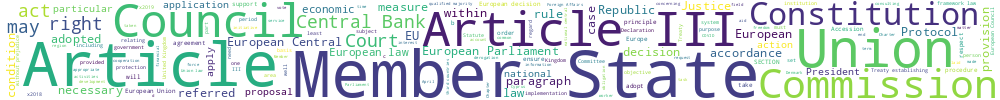

In [15]:
def my_word_cloud():
    all_text = ""
    
    for filename in files:
        with open(os.path.join(doc_dir, filename), 'r', encoding='utf-8') as f:
            all_text += f.read() + " "
    wordcloud = WordCloud(
        background_color="white", 
        max_words=2000,
        width=1000,
        height=100,
        contour_width=3, 
    ).generate(all_text)
    
    return wordcloud.to_image()

my_word_cloud()

Zastanówmy się nad jeszcze jednym zagadnieniem - jak pogrupować te terminy ze względu na dziedzinę? Zagadnienie to nosi nazwę klasyfikacji tematycznej. A dzięki pewnemu XIX-wiecznemu niemieckiemu matematykowi możliwe jest przeprowadzenie tego procesu automatycznie. Matematyk ten nosił nazwisko Peter Gustav Lejeune Dirichlet, a metoda klasyfikacji nazywa się LDA (**L**atent **D**irichlet **A**llocation).

### Ćwiczenie 5: Wykonaj tutorial dostępny pod https://towardsdatascience.com/end-to-end-topic-modeling-in-python-latent-dirichlet-allocation-lda-35ce4ed6b3e0. Wklej do notatnika wyniki.

In [16]:
!pip install pyLDAvis


  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 4.7 MB/s eta 0:00:00a 0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)
Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 6.0 MB/s eta 0:00:0000:0100:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [17]:
import os
import re
import pandas as pd

data_list = []
for filename in files:
    with open(os.path.join(doc_dir, filename), 'r', encoding='utf-8') as f:
        data_list.append(f.read())

papers = pd.DataFrame(data_list, columns=['paper_text'])
papers['paper_text_processed'] = papers['paper_text'].map(lambda x: re.sub('[,\.!?]', '', x))
papers['paper_text_processed'] = papers['paper_text_processed'].map(lambda x: x.lower())
print(papers['paper_text_processed'].head())

0    the commission may take any useful initiative ...
1    protocol on the convergence criteria the deleg...
2    it must be respected and protected 5 (a) algir...
3    6 2006 the commission shall within four months...
4    3 germany the high contracting parties für sei...
Name: paper_text_processed, dtype: str


<>:11: SyntaxWarning: invalid escape sequence '\.'
<>:11: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_31899/79614220.py:11: SyntaxWarning: invalid escape sequence '\.'
  papers['paper_text_processed'] = papers['paper_text'].map(lambda x: re.sub('[,\.!?]', '', x))


['european', 'medicines', 'agency', 'emea', 'european', 'public', 'assessment', 'report', 'epar', 'vidaza', 'epar', 'summary', 'public', 'document', 'summary', 'european', 'public', 'assessment', 'report', 'epar', 'explains', 'committee', 'medicinal', 'products', 'human', 'chmp', 'assessed', 'studies', 'performed', 'reach']

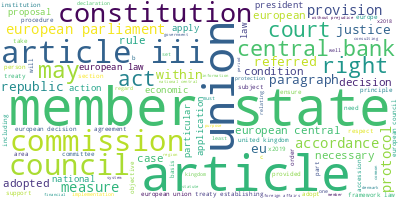

In [18]:
from wordcloud import WordCloud

long_string = ','.join(list(papers['paper_text_processed'].values))
wordcloud = WordCloud(background_color="white", max_words=5000, contour_width=3, contour_color='steelblue')
wordcloud.generate(long_string)

wordcloud.to_image()

In [20]:
import gensim
from gensim.utils import simple_preprocess
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = stopwords.words('english')
stop_words.extend(['from', 'subject', 're', 'edu', 'use', 'also', 'say'])

def sent_to_words(sentences):
    for sentence in sentences:
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))

def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc)) if word not in stop_words] for doc in texts]

data = papers.paper_text_processed.values.tolist()
data_words = list(sent_to_words(data))
data_words = remove_stopwords(data_words)

print(data_words[:1][0][:30])

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/dbanaszak/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


['commission', 'may', 'take', 'useful', 'initiative', 'promote', 'coordination', 'actions', 'union', 'member', 'states', 'order', 'enhance', 'efficiency', 'complementarity', 'union', 'national', 'humanitarian', 'aid', 'measures', 'board', 'governors', 'acting', 'unanimously', 'shall', 'establish', 'statutes', 'bodies', 'referred', 'paragraph']


['european', 'medicines', 'agency', 'emea', 'european', 'public', 'assessment', 'report', 'epar', 'vidaza', 'epar', 'summary', 'public', 'document', 'summary', 'european', 'public', 'assessment', 'report', 'epar', 'explains', 'committee', 'medicinal', 'products', 'human', 'chmp', 'assessed', 'studies', 'performed', 'reach']

In [21]:
import gensim.corpora as corpora

id2word = corpora.Dictionary(data_words)
texts = data_words
corpus = [id2word.doc2bow(text) for text in texts]

print(corpus[:1][0][:30])

[(0, 4), (1, 1), (2, 2), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 2), (10, 1), (11, 3), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 2), (18, 2), (19, 1), (20, 1), (21, 2), (22, 3), (23, 5), (24, 1), (25, 2), (26, 3), (27, 1), (28, 1), (29, 2)]


[(0, 1), (1, 4), (2, 1), (3, 3), (4, 2), (5, 1), (6, 1), (7, 2), (8, 2), (9, 2), (10, 1), (11, 2), (12, 2), (13, 2), (14, 3), (15, 2), (16, 1), (17, 1), (18, 1), (19, 8), (20, 1), (21, 3), (22, 1), (23, 1), (24, 2), (25, 1), (26, 1), (27, 1), (28, 2), (29, 1)]

In [22]:
from pprint import pprint
num_topics = 3
lda_model = gensim.models.LdaMulticore(corpus=corpus,
                                       id2word=id2word,
                                       num_topics=num_topics)
pprint(lda_model.print_topics())

[(0,
  '0.029*"shall" + 0.023*"european" + 0.022*"article" + 0.016*"member" + '
  '0.015*"union" + 0.012*"states" + 0.012*"iii" + 0.011*"council" + '
  '0.008*"may" + 0.007*"commission"'),
 (1,
  '0.033*"shall" + 0.022*"article" + 0.020*"european" + 0.016*"member" + '
  '0.012*"council" + 0.012*"union" + 0.012*"states" + 0.010*"iii" + '
  '0.008*"commission" + 0.007*"may"'),
 (2,
  '0.033*"shall" + 0.017*"article" + 0.016*"european" + 0.015*"union" + '
  '0.012*"member" + 0.009*"iii" + 0.009*"states" + 0.008*"council" + '
  '0.007*"commission" + 0.007*"may"')]


[(0,
  '0.016*"insulin" + 0.013*"patients" + 0.012*"may" + 0.007*"pioglitazone" + '
  '0.006*"mg" + 0.006*"dose" + 0.005*"treatment" + 0.005*"tablets" + '
  '0.004*"injection" + 0.004*"tel"'),
 (1,
  '0.017*"insulin" + 0.013*"patients" + 0.009*"may" + 0.006*"mg" + '
  '0.006*"blood" + 0.006*"treatment" + 0.006*"pioglitazone" + 0.005*"dose" + '
  '0.005*"tablets" + 0.005*"injection"'),
 (2,
  '0.018*"insulin" + 0.014*"may" + 0.007*"mg" + 0.007*"patients" + '
  '0.006*"dose" + 0.006*"injection" + 0.006*"medicinal" + 0.005*"enviage" + '
  '0.005*"blood" + 0.005*"ml"')]

In [23]:
import pyLDAvis.gensim_models
import pyLDAvis

pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, id2word)

vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.001879 -0.001341       1        1  58.540117
1     -0.001224  0.001544       2        1  37.822340
2      0.003103 -0.000203       3        1   3.637543, topic_info=         Term         Freq        Total Category  logprob  loglift
481     shall  2583.000000  2583.000000  Default  30.0000  30.0000
52    article  1854.000000  1854.000000  Default  29.0000  29.0000
200  european  1820.000000  1820.000000  Default  28.0000  28.0000
540     union  1177.000000  1177.000000  Default  27.0000  27.0000
332    member  1357.000000  1357.000000  Default  26.0000  26.0000
..        ...          ...          ...      ...      ...      ...
134   council    24.264262   996.669624   Topic3  -4.8465  -0.4016
455  republic    12.705161   388.130294   Topic3  -5.4935  -0.1055
343  national    10.627595   320.662445   Topic3  -5.6721  -0.0931
9         act    10.540185   319.596574   Topic3  -5.6803  -0.0980
62       bank    10.521141   378.016559   Topic3  -5.6821  -0.2677

[285 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
571       1  0.708199   accession
571       2  0.263045   accession
571       3  0.033724   accession
2         1  0.540975  accordance
2         2  0.428939  accordance
...     ...       ...         ...
560       3  0.046411     without
5337      1  0.686532         wto
5337      2  0.343266         wto
4824      1  0.566721          xv
4824      2  0.566721          xv

[490 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3])